In [1]:
import sys
sys.path.append('../datasets')
sys.path.append('../algorithms')
sys.path.append('../test')


import torch

import matplotlib.pyplot as plt

from pansharpening import PANDataset
from gradient_prox_1 import ProximalGradient
from torchvision import transforms
from math import sqrt

In [2]:
# Define device (default is "cpu")
device = "cpu" 

    # Define dtype
dtype = torch.float64

    # Define random seed
seed = 42
torch.manual_seed(seed)

    # Define data path
data_path = '/home/ndiayem/Documents/spectral-spatial/data/harvard.zarr'

In [3]:
val_transform = transforms.Compose([transforms.ToTensor()]) # Transforms a the input data to torch tensors
dataset = PANDataset(root_dir=data_path, split='train', transform= val_transform)

In [4]:
idx = 17
X = dataset[idx]
X = X.unsqueeze(0)

In [5]:
# Matrice de transformation
Y_H = dataset.simule_low_hsi(X)  
Y_M = dataset.get_panchromatic(X)
Y_M = Y_M

In [10]:
pansharpening_model = ProximalGradient(dataset.simule_low_hsi,dataset.simule_low_hsi_adjoint ,max_iter=100, lmbda=0.5, lmbda_m=2, tau=0.01,tol=1e-7 ,scale = 4,verbose=True)


In [11]:
# Exécution de l'optimisation
U_result = pansharpening_model.forward(Y_H, Y_M)

  0%|          | 0/100 [00:00<?, ?it/s]

In [12]:
U_result.shape

torch.Size([1, 31, 1040, 1392])

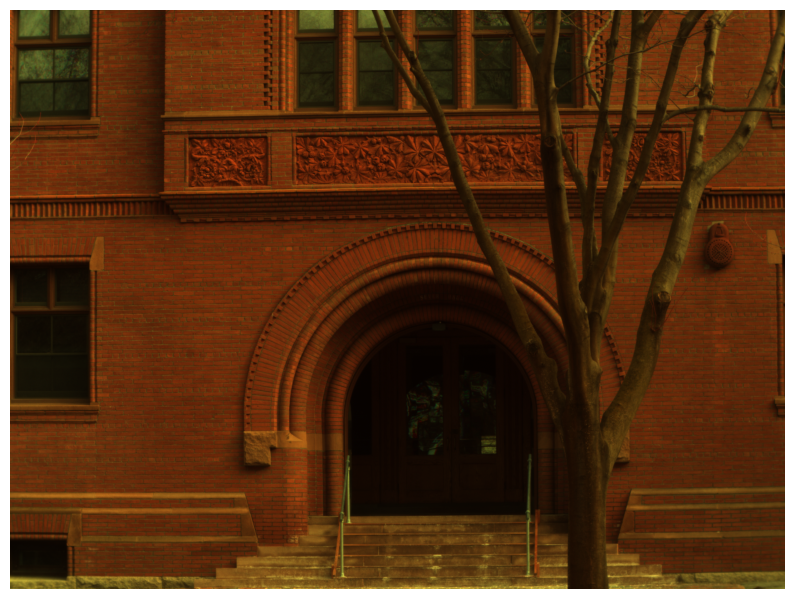

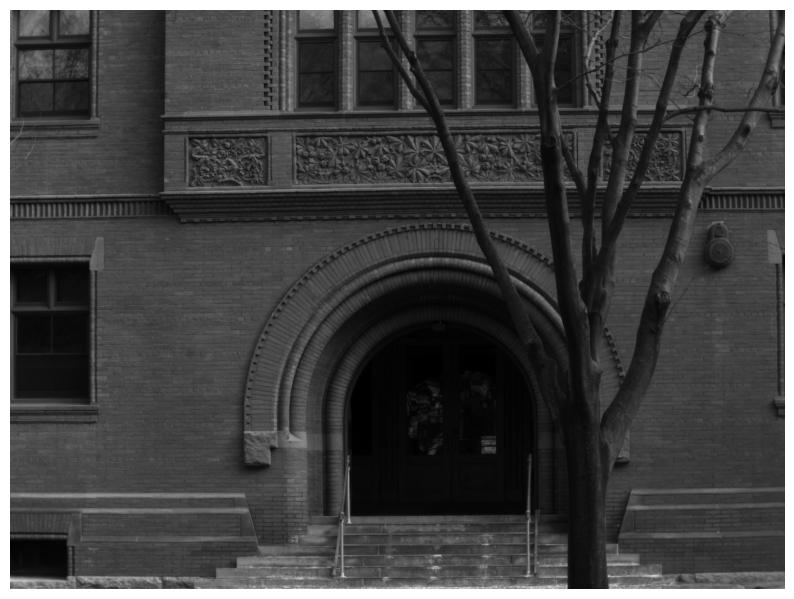

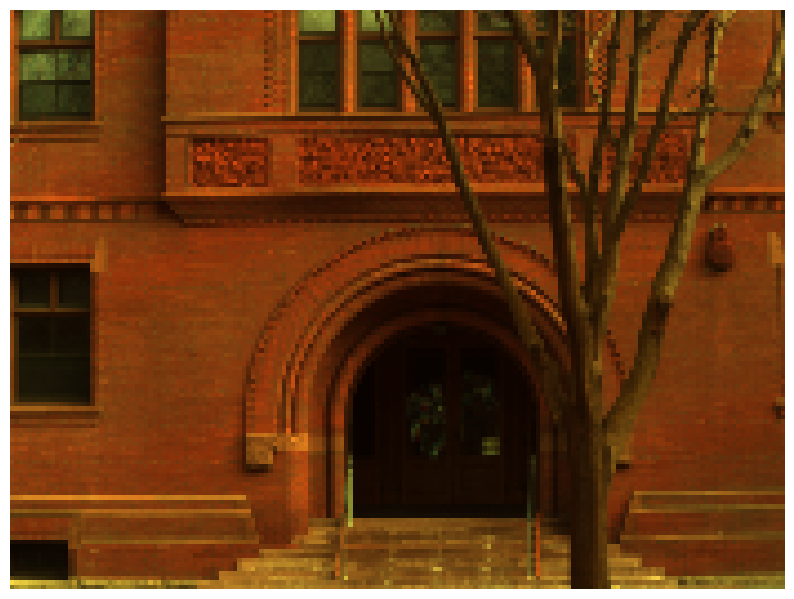

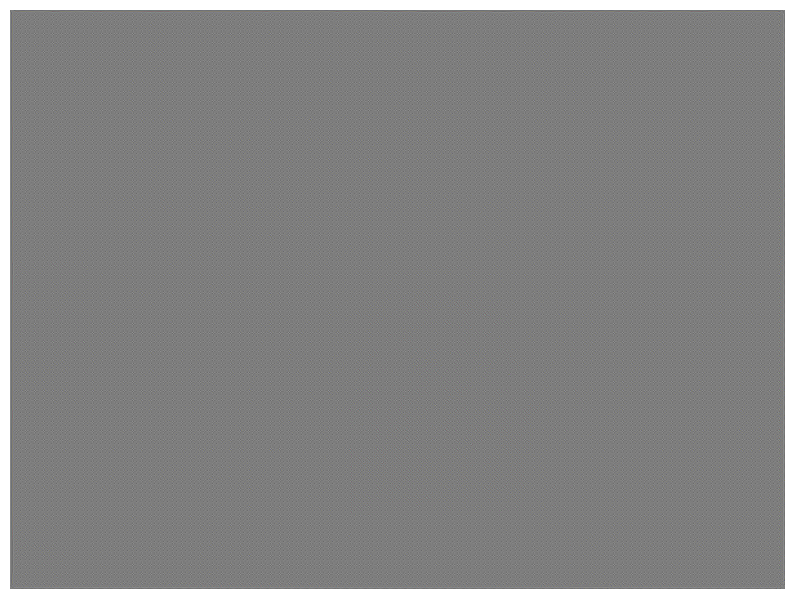

In [13]:
rgb = dataset.rgb_index
x_rgb = X[0, rgb,...].cpu().numpy().transpose(1, 2, 0)
x_rgb = (x_rgb - x_rgb.min())/(x_rgb.max() - x_rgb.min())

y_rgb = Y_H[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
y_rgb = (y_rgb - y_rgb.min())/(y_rgb.max() - y_rgb.min())

z_rgb = U_result[0, rgb, ...].cpu().numpy().transpose(1, 2, 0)
z_rgb = (z_rgb - z_rgb.min())/(z_rgb.max() - z_rgb.min())

# plt.figure(figsize=(15, 5))
# plt.subplot(131)
plt.figure(figsize=(10,10))
plt.imshow(x_rgb)
# plt.title('RGB')
plt.axis('off')

# plt.subplot(132)
plt.figure(figsize=(10,10))
plt.imshow(Y_M[0, 0, ...].cpu().numpy(), cmap='gray')
# plt.title('Panchromatic')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(y_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

# plt.subplot(133)
plt.figure(figsize=(10,10))
plt.imshow(z_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

plt.show()